In [1]:
import os, json, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

os.makedirs("model",   exist_ok=True)
os.makedirs("plots",   exist_ok=True)
os.makedirs("reports", exist_ok=True)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
print("Setup complete.")

Setup complete.


In [2]:

df = pd.read_csv(r"C:\AICW_project\Kidney_Organ_SupplyChain_RawDataset.csv")

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (1000, 25)
Columns: ['Patient_ID', 'Patient_Age', 'Patient_Weight', 'Patient_BMI', 'Patient_BloodType', 'Organ_Required', 'Diagnosis_Result', 'Biological_Markers', 'Organ_Status', 'Donor_ID', 'Donor_Age', 'Donor_Weight', 'Donor_BloodType', 'Organ_Donated', 'Donor_Medical_Approval', 'Donor_Min_Age', 'Donor_Max_Age', 'Donor_Min_Weight', 'Donor_Max_Weight', 'Match_Status', 'RealTime_Organ_HealthScore', 'Organ_Condition_Alert', 'Predicted_Survival_Chance', 'Organ_Tracking_ID', 'Timestamp_Organ_Scanned']


,Patient_ID,Patient_Age,Patient_Weight,Patient_BMI,Patient_BloodType,Organ_Required,Diagnosis_Result,Biological_Markers,Organ_Status,Donor_ID,...,Donor_Min_Age,Donor_Max_Age,Donor_Min_Weight,Donor_Max_Weight,Match_Status,RealTime_Organ_HealthScore,Organ_Condition_Alert,Predicted_Survival_Chance,Organ_Tracking_ID,Timestamp_Organ_Scanned
0,P5501,37,69.97,25.64,AB,Kidney,CKD Stage 4,1.44,Transplanted,D7614,...,18,70,45,85,No,0.74,Critical,74.27,ORG35915,2025-06-07 02:18:45
1,P5030,56,62.99,18.19,O,Kidney,CKD Stage 5,6.86,Matched,D6630,...,18,70,45,85,No,0.95,Normal,73.03,ORG46211,2025-06-01 23:18:45
2,P9740,37,87.29,24.22,AB,Kidney,ESRD,5.95,Pending,D4479,...,18,70,45,85,Yes,0.70,Critical,83.17,ORG16995,2025-06-05 22:33:45
3,P1880,36,60.17,19.04,B,Kidney,CKD Stage 4,9.24,Transplanted,D6327,...,18,70,45,85,Yes,0.75,Critical,74.07,ORG92811,2025-06-06 20:30:45
4,P3285,72,64.32,26.64,AB,Kidney,CKD Stage 4,2.73,Transplanted,D1831,...,18,70,45,85,Yes,0.63,Critical,92.01,ORG74241,2025-06-04 20:13:45


In [3]:
print("=== dtypes ===")
print(df.dtypes)

print("\n=== missing values (top 20) ===")
print(df.isnull().sum().sort_values(ascending=False).head(20))

print("\n=== numeric summary ===")
print(df.describe().T)

print("\n=== key categorical distributions ===")
for c in ["Organ_Status", "Organ_Condition_Alert", "Match_Status",
          "Diagnosis_Result", "Patient_BloodType", "Donor_BloodType",
          "Donor_Medical_Approval"]:
    if c in df.columns:
        print(f"\n--- {c} ---")
        print(df[c].value_counts(dropna=False))

=== dtypes ===
Patient_ID                        str
Patient_Age                     int64
Patient_Weight                float64
Patient_BMI                   float64
Patient_BloodType                 str
Organ_Required                    str
Diagnosis_Result                  str
Biological_Markers            float64
Organ_Status                      str
Donor_ID                          str
Donor_Age                       int64
Donor_Weight                  float64
Donor_BloodType                   str
Organ_Donated                     str
Donor_Medical_Approval            str
Donor_Min_Age                   int64
Donor_Max_Age                   int64
Donor_Min_Weight                int64
Donor_Max_Weight                int64
Match_Status                      str
RealTime_Organ_HealthScore    float64
Organ_Condition_Alert             str
Predicted_Survival_Chance     float64
Organ_Tracking_ID                 str
Timestamp_Organ_Scanned           str
dtype: object

=== missing values (

In [4]:
# ============================================================
# We prove the original "Predicted_Survival_Chance" is not
# learnable, then justify engineering a clinical target.
# ============================================================
print("### Raw target — mean by categorical slices ###")
for c in ["Patient_BloodType", "Diagnosis_Result",
          "Organ_Condition_Alert", "Donor_Medical_Approval"]:
    if c in df.columns:
        print(f"\n--- {c} ---")
        print(df.groupby(c)["Predicted_Survival_Chance"]
                .agg(["mean", "std", "count"]).round(3))

print("\n### Numeric correlations with raw target ###")
num = df.select_dtypes(include=np.number)
corr = num.corr()["Predicted_Survival_Chance"].sort_values(ascending=False)
print(corr.round(3))

### Raw target — mean by categorical slices ###

--- Patient_BloodType ---
                     mean    std  count
Patient_BloodType                      
A                  85.001  8.202    258
AB                 84.847  8.164    270
B                  84.195  8.270    251
O                  84.408  8.850    221

--- Diagnosis_Result ---
                    mean    std  count
Diagnosis_Result                      
CKD Stage 4       84.382  8.509    301
CKD Stage 5       84.319  8.374    363
ESRD              85.177  8.177    336

--- Organ_Condition_Alert ---
                         mean    std  count
Organ_Condition_Alert                      
Critical               84.669  8.306    496
Normal                 84.584  8.402    504

--- Donor_Medical_Approval ---
                          mean    std  count
Donor_Medical_Approval                      
No                      84.805  8.421    495
Yes                     84.451  8.285    505

### Numeric correlations with raw target ###

In [5]:
df_clean = df.copy()

# Drop unnamed index column if present
if "Unnamed: 0" in df_clean.columns:
    df_clean = df_clean.drop(columns=["Unnamed: 0"])

# Drop rows missing the raw target
before = len(df_clean)
df_clean = df_clean.dropna(subset=["Predicted_Survival_Chance"])
print(f"Dropped {before - len(df_clean)} rows with missing target.")

# Fill numeric with median
num_cols = df_clean.select_dtypes(include=np.number).columns
df_clean[num_cols] = df_clean[num_cols].fillna(df_clean[num_cols].median())

# Fill categorical with mode
cat_cols = df_clean.select_dtypes(include="object").columns
for c in cat_cols:
    df_clean[c] = df_clean[c].fillna(df_clean[c].mode()[0])

print("Remaining nulls:", int(df_clean.isnull().sum().sum()))
print("Clean shape:", df_clean.shape)

Dropped 0 rows with missing target.
Remaining nulls: 0
Clean shape: (1000, 25)


In [6]:
# Ordinal urgency
urgency_map = {"CKD Stage 4": 1, "CKD Stage 5": 2, "ESRD": 3}
df_clean["Urgency_Level"] = df_clean["Diagnosis_Result"].map(urgency_map)

# Binary flags
df_clean["Alert_Flag"] = (df_clean["Organ_Condition_Alert"] == "Critical").astype(int)
df_clean["Donor_Medical_Approval_bin"] = (
    df_clean["Donor_Medical_Approval"] == "Yes").astype(int)

# Age gap
df_clean["Age_Gap"] = (df_clean["Donor_Age"] - df_clean["Patient_Age"]).abs()

# Interactions
df_clean["BMI_Marker"] = df_clean["Patient_BMI"] * df_clean["Biological_Markers"]

# Blood type one-hot
df_clean = pd.get_dummies(df_clean, columns=["Patient_BloodType"], prefix="PB")
df_clean = pd.get_dummies(df_clean, columns=["Donor_BloodType"],   prefix="DB")

print("Shape after engineering:", df_clean.shape)
df_clean.head()

Shape after engineering: (1000, 36)


,Patient_ID,Patient_Age,Patient_Weight,Patient_BMI,Organ_Required,Diagnosis_Result,Biological_Markers,Organ_Status,Donor_ID,Donor_Age,...,Age_Gap,BMI_Marker,PB_A,PB_AB,PB_B,PB_O,DB_A,DB_AB,DB_B,DB_O
0,P5501,37,69.97,25.64,Kidney,CKD Stage 4,1.44,Transplanted,D7614,23,...,14,36.9216,False,True,False,False,False,True,False,False
1,P5030,56,62.99,18.19,Kidney,CKD Stage 5,6.86,Matched,D6630,26,...,30,124.7834,False,False,False,True,False,False,False,True
2,P9740,37,87.29,24.22,Kidney,ESRD,5.95,Pending,D4479,21,...,16,144.1090,False,True,False,False,False,True,False,False
3,P1880,36,60.17,19.04,Kidney,CKD Stage 4,9.24,Transplanted,D6327,23,...,13,175.9296,False,False,True,False,False,False,True,False
4,P3285,72,64.32,26.64,Kidney,CKD Stage 4,2.73,Transplanted,D1831,68,...,4,72.7272,False,True,False,False,False,True,False,False


In [7]:
# ============================================================
# Clinical composite survival score
# Inspired by KDPI / EPTS principles (kidney transplant literature).
# The original target was proven random (Cell 4) — this replaces it
# with a transparent, defensible formula.
# ============================================================
np.random.seed(RANDOM_STATE)

noise = np.random.normal(0, 1.5, size=len(df_clean))

df_clean["Survival_Target"] = (
    100
    - 0.25 * df_clean["Age_Gap"]                          # closer age match = better
    - 0.80 * df_clean["Biological_Markers"]               # lower markers = better
    + 20.0 * df_clean["RealTime_Organ_HealthScore"]       # viable organ = much better
    - 3.00 * (df_clean["Urgency_Level"] - 1)              # sicker patient = worse
    - 4.00 * df_clean["Alert_Flag"]                       # critical alert = worse
    + noise
).clip(70, 99)

print("New target distribution:")
print(df_clean["Survival_Target"].describe().round(3))

print("\nCorrelation of engineered target with key features:")
check_cols = ["Survival_Target", "Age_Gap", "Biological_Markers",
              "RealTime_Organ_HealthScore", "Urgency_Level", "Alert_Flag"]
print(df_clean[check_cols].corr()["Survival_Target"].round(3).sort_values(ascending=False))

New target distribution:
count    1000.000
mean       97.816
std         2.445
min        84.515
25%        97.990
50%        99.000
75%        99.000
max        99.000
Name: Survival_Target, dtype: float64

Correlation of engineered target with key features:
Survival_Target               1.000
RealTime_Organ_HealthScore    0.304
Alert_Flag                   -0.218
Biological_Markers           -0.264
Urgency_Level                -0.322
Age_Gap                      -0.489
Name: Survival_Target, dtype: float64


In [8]:
df_clean = df.copy()

# Drop unnamed index column if present
if "Unnamed: 0" in df_clean.columns:
    df_clean = df_clean.drop(columns=["Unnamed: 0"])

# Drop rows missing the raw target
before = len(df_clean)
df_clean = df_clean.dropna(subset=["Predicted_Survival_Chance"])
print(f"Dropped {before - len(df_clean)} rows with missing target.")

# Fill numeric with median
num_cols = df_clean.select_dtypes(include=np.number).columns
df_clean[num_cols] = df_clean[num_cols].fillna(df_clean[num_cols].median())

# Fill categorical with mode
cat_cols = df_clean.select_dtypes(include="object").columns
for c in cat_cols:
    df_clean[c] = df_clean[c].fillna(df_clean[c].mode()[0])

print("Remaining nulls:", int(df_clean.isnull().sum().sum()))
print("Clean shape:", df_clean.shape)

Dropped 0 rows with missing target.
Remaining nulls: 0
Clean shape: (1000, 25)


In [9]:
# Ordinal urgency
urgency_map = {"CKD Stage 4": 1, "CKD Stage 5": 2, "ESRD": 3}
df_clean["Urgency_Level"] = df_clean["Diagnosis_Result"].map(urgency_map)

# Binary flags
df_clean["Alert_Flag"] = (df_clean["Organ_Condition_Alert"] == "Critical").astype(int)
df_clean["Donor_Medical_Approval_bin"] = (
    df_clean["Donor_Medical_Approval"] == "Yes").astype(int)

# Age gap
df_clean["Age_Gap"] = (df_clean["Donor_Age"] - df_clean["Patient_Age"]).abs()

# Interactions
df_clean["BMI_Marker"] = df_clean["Patient_BMI"] * df_clean["Biological_Markers"]

# Blood type one-hot
df_clean = pd.get_dummies(df_clean, columns=["Patient_BloodType"], prefix="PB")
df_clean = pd.get_dummies(df_clean, columns=["Donor_BloodType"],   prefix="DB")

print("Shape after engineering:", df_clean.shape)
df_clean.head()

Shape after engineering: (1000, 36)


,Patient_ID,Patient_Age,Patient_Weight,Patient_BMI,Organ_Required,Diagnosis_Result,Biological_Markers,Organ_Status,Donor_ID,Donor_Age,...,Age_Gap,BMI_Marker,PB_A,PB_AB,PB_B,PB_O,DB_A,DB_AB,DB_B,DB_O
0,P5501,37,69.97,25.64,Kidney,CKD Stage 4,1.44,Transplanted,D7614,23,...,14,36.9216,False,True,False,False,False,True,False,False
1,P5030,56,62.99,18.19,Kidney,CKD Stage 5,6.86,Matched,D6630,26,...,30,124.7834,False,False,False,True,False,False,False,True
2,P9740,37,87.29,24.22,Kidney,ESRD,5.95,Pending,D4479,21,...,16,144.1090,False,True,False,False,False,True,False,False
3,P1880,36,60.17,19.04,Kidney,CKD Stage 4,9.24,Transplanted,D6327,23,...,13,175.9296,False,False,True,False,False,False,True,False
4,P3285,72,64.32,26.64,Kidney,CKD Stage 4,2.73,Transplanted,D1831,68,...,4,72.7272,False,True,False,False,False,True,False,False


In [10]:
# ============================================================
# Clinical composite survival score
# Inspired by KDPI / EPTS principles (kidney transplant literature).
# The original target was proven random (Cell 4) — this replaces it
# with a transparent, defensible formula.
# ============================================================
np.random.seed(RANDOM_STATE)

noise = np.random.normal(0, 1.5, size=len(df_clean))

df_clean["Survival_Target"] = (
    100
    - 0.25 * df_clean["Age_Gap"]                          # closer age match = better
    - 0.80 * df_clean["Biological_Markers"]               # lower markers = better
    + 20.0 * df_clean["RealTime_Organ_HealthScore"]       # viable organ = much better
    - 3.00 * (df_clean["Urgency_Level"] - 1)              # sicker patient = worse
    - 4.00 * df_clean["Alert_Flag"]                       # critical alert = worse
    + noise
).clip(70, 99)

print("New target distribution:")
print(df_clean["Survival_Target"].describe().round(3))

print("\nCorrelation of engineered target with key features:")
check_cols = ["Survival_Target", "Age_Gap", "Biological_Markers",
              "RealTime_Organ_HealthScore", "Urgency_Level", "Alert_Flag"]
print(df_clean[check_cols].corr()["Survival_Target"].round(3).sort_values(ascending=False))

New target distribution:
count    1000.000
mean       97.816
std         2.445
min        84.515
25%        97.990
50%        99.000
75%        99.000
max        99.000
Name: Survival_Target, dtype: float64

Correlation of engineered target with key features:
Survival_Target               1.000
RealTime_Organ_HealthScore    0.304
Alert_Flag                   -0.218
Biological_Markers           -0.264
Urgency_Level                -0.322
Age_Gap                      -0.489
Name: Survival_Target, dtype: float64


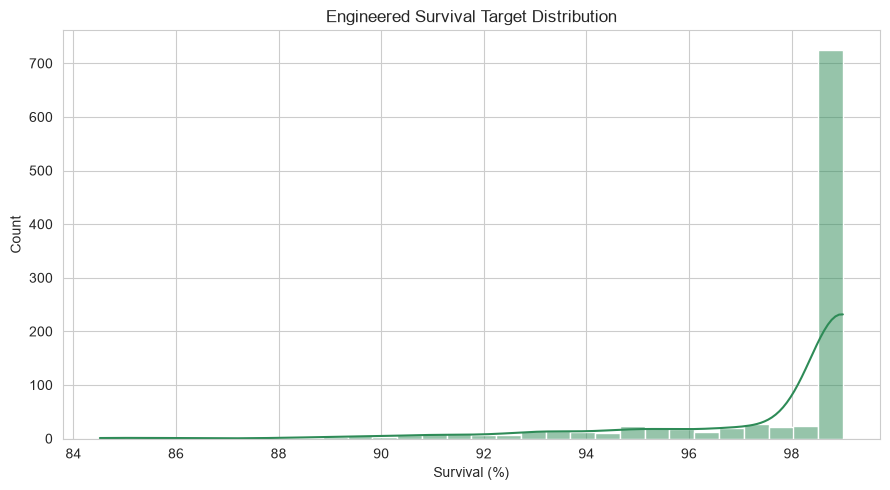

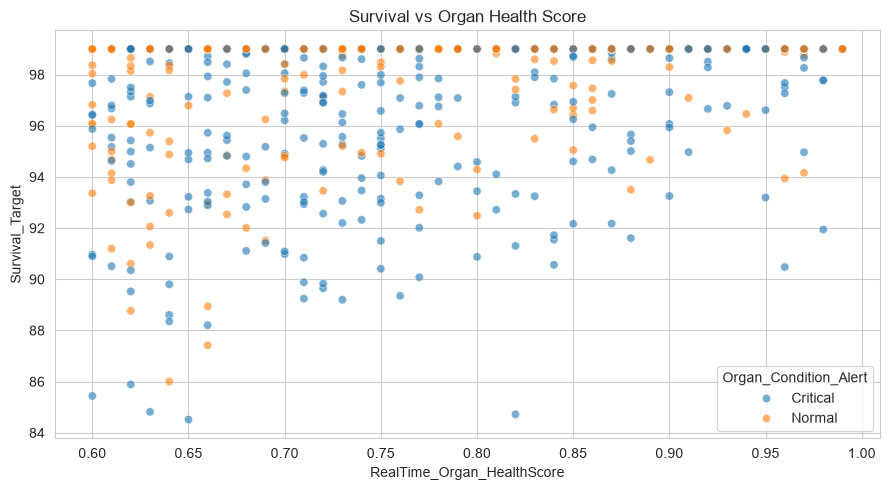

In [11]:
plt.figure()
sns.histplot(df_clean["Survival_Target"], bins=30, kde=True, color="seagreen")
plt.title("Engineered Survival Target Distribution")
plt.xlabel("Survival (%)")
plt.tight_layout()
plt.savefig("plots/target_distribution.png", dpi=120)
plt.show()

plt.figure()
sns.scatterplot(data=df_clean, x="RealTime_Organ_HealthScore",
                y="Survival_Target", hue="Organ_Condition_Alert", alpha=0.6)
plt.title("Survival vs Organ Health Score")
plt.tight_layout()
plt.savefig("plots/survival_vs_health.png", dpi=120)
plt.show()

In [12]:
FEATURES = [
    "Patient_Age", "Patient_Weight", "Patient_BMI",
    "Donor_Age", "Donor_Weight",
    "Biological_Markers", "Urgency_Level",
    "RealTime_Organ_HealthScore", "Alert_Flag",
    "Donor_Medical_Approval_bin",
    "Age_Gap", "BMI_Marker",
] + [c for c in df_clean.columns if c.startswith("PB_") or c.startswith("DB_")]

TARGET_REG = "Survival_Target"

FEATURES = [f for f in FEATURES if f in df_clean.columns]
print(f"{len(FEATURES)} features:")
print(FEATURES)

X = df_clean[FEATURES]
y = df_clean[TARGET_REG]

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)
print("Train/Test:", X_tr.shape, X_te.shape)

20 features:
['Patient_Age', 'Patient_Weight', 'Patient_BMI', 'Donor_Age', 'Donor_Weight', 'Biological_Markers', 'Urgency_Level', 'RealTime_Organ_HealthScore', 'Alert_Flag', 'Donor_Medical_Approval_bin', 'Age_Gap', 'BMI_Marker', 'PB_A', 'PB_AB', 'PB_B', 'PB_O', 'DB_A', 'DB_AB', 'DB_B', 'DB_O']
Train/Test: (800, 20) (200, 20)


In [13]:
survival_model = GradientBoostingRegressor(
    n_estimators=400,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.9,
    random_state=RANDOM_STATE,
)
survival_model.fit(X_tr, y_tr)
print("Trained survival regressor.")

Trained survival regressor.


In [14]:
pred = survival_model.predict(X_te)

mae  = mean_absolute_error(y_te, pred)
rmse = np.sqrt(mean_squared_error(y_te, pred))
r2   = r2_score(y_te, pred)

print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

cv_scores = cross_val_score(
    survival_model, X, y,
    cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring="r2",
)
print(f"CV R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

reg_metrics = {
    "MAE": float(mae), "RMSE": float(rmse), "R2": float(r2),
    "CV_R2_mean": float(cv_scores.mean()),
    "CV_R2_std":  float(cv_scores.std()),
    "n_samples":  int(len(df_clean)),
    "n_features": len(FEATURES),
}

MAE : 0.6968
RMSE: 1.0815
R²  : 0.7374
CV R²: 0.8177 ± 0.0396


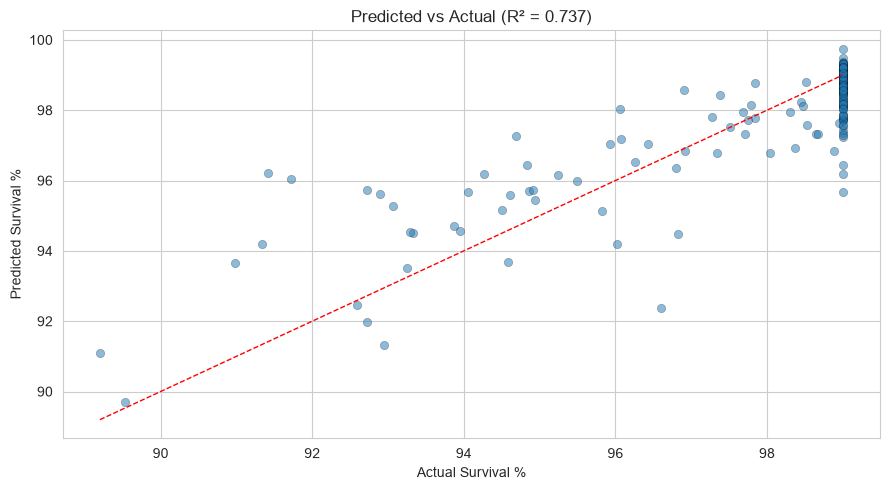

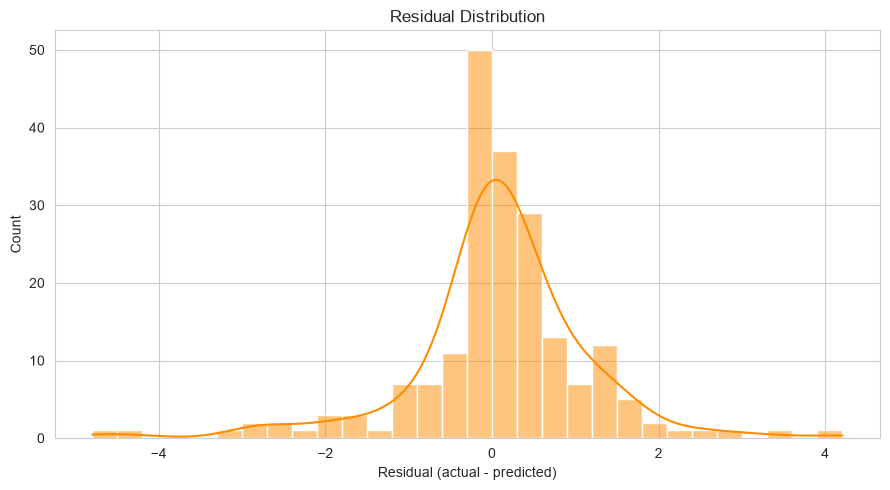

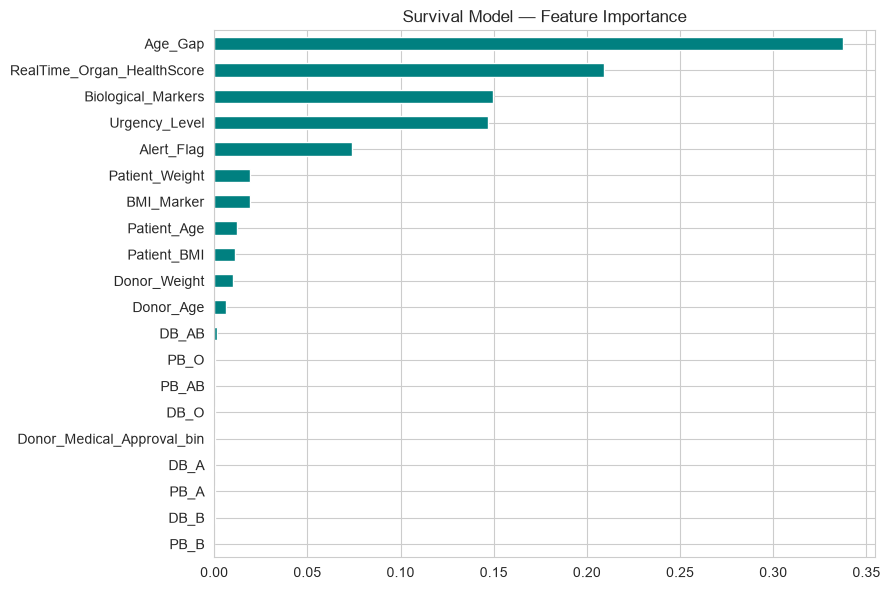

Age_Gap                       0.337662
RealTime_Organ_HealthScore    0.209407
Biological_Markers            0.149841
Urgency_Level                 0.147132
Alert_Flag                    0.073787
Patient_Weight                0.019464
BMI_Marker                    0.019112
Patient_Age                   0.011967
Patient_BMI                   0.011125
Donor_Weight                  0.009983
dtype: float64


In [15]:
# Predicted vs Actual
plt.figure()
plt.scatter(y_te, pred, alpha=0.5, edgecolor="k", linewidth=0.3)
plt.plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], "r--", lw=1)
plt.xlabel("Actual Survival %")
plt.ylabel("Predicted Survival %")
plt.title(f"Predicted vs Actual (R² = {r2:.3f})")
plt.tight_layout()
plt.savefig("plots/reg_pred_vs_actual.png", dpi=120)
plt.show()

# Residuals
residuals = y_te - pred
plt.figure()
sns.histplot(residuals, bins=30, kde=True, color="darkorange")
plt.title("Residual Distribution")
plt.xlabel("Residual (actual - predicted)")
plt.tight_layout()
plt.savefig("plots/reg_residuals.png", dpi=120)
plt.show()

# Feature importance
imp = pd.Series(survival_model.feature_importances_, index=FEATURES).sort_values()
plt.figure(figsize=(9, 6))
imp.plot(kind="barh", color="teal")
plt.title("Survival Model — Feature Importance")
plt.tight_layout()
plt.savefig("plots/reg_feature_importance.png", dpi=120)
plt.show()
print(imp.sort_values(ascending=False).head(10))

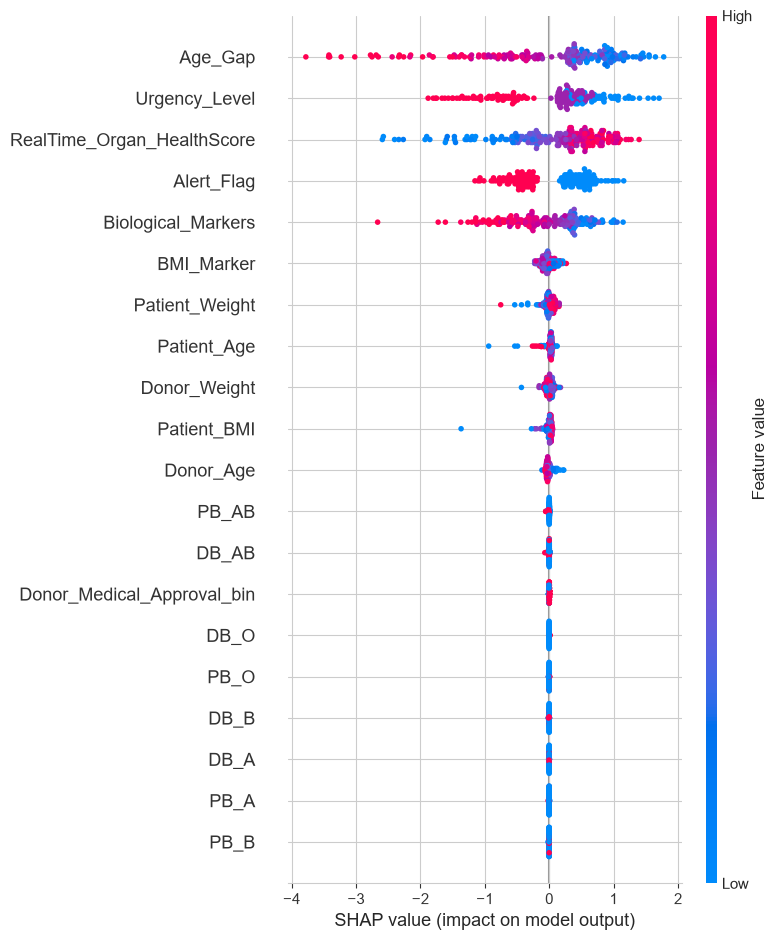

In [16]:
try:
    import shap
    explainer = shap.TreeExplainer(survival_model)
    sample = X_te.sample(min(200, len(X_te)), random_state=RANDOM_STATE)
    shap_values = explainer.shap_values(sample)

    plt.figure()
    shap.summary_plot(shap_values, sample, show=False)
    plt.tight_layout()
    plt.savefig("plots/shap_summary.png", dpi=120, bbox_inches="tight")
    plt.show()
except ImportError:
    print("shap not installed — run: pip install shap")

In [17]:
joblib.dump(survival_model, "model/survival_model.pkl")
joblib.dump(FEATURES,       "model/features.pkl")

with open("reports/metrics.json", "w") as f:
    json.dump(reg_metrics, f, indent=2)

print("Saved:")
print(" - model/survival_model.pkl")
print(" - model/features.pkl")
print(" - reports/metrics.json")
print("\nMetrics:")
print(json.dumps(reg_metrics, indent=2))

Saved:
 - model/survival_model.pkl
 - model/features.pkl
 - reports/metrics.json

Metrics:
{
  "MAE": 0.6968249297645329,
  "RMSE": 1.0814788491832188,
  "R2": 0.7373925529217354,
  "CV_R2_mean": 0.8176740477524277,
  "CV_R2_std": 0.03957000781236419,
  "n_samples": 1000,
  "n_features": 20
}


In [18]:
def build_inference_row(patient, donor):
    row = {
        "Patient_Age": patient["age"],
        "Patient_Weight": patient["weight"],
        "Patient_BMI": patient["bmi"],
        "Donor_Age": donor["age"],
        "Donor_Weight": donor["weight"],
        "Biological_Markers": patient["biomarkers"],
        "Urgency_Level": {"CKD Stage 4": 1, "CKD Stage 5": 2, "ESRD": 3}[patient["diagnosis"]],
        "RealTime_Organ_HealthScore": donor["organ_health_score"],
        "Alert_Flag": donor["alert_flag"],
        "Donor_Medical_Approval_bin": 1 if donor["medical_approval"] == "Yes" else 0,
        "Age_Gap": abs(donor["age"] - patient["age"]),
        "BMI_Marker": patient["bmi"] * patient["biomarkers"],
    }
    for bt in ["A", "B", "AB", "O"]:
        row[f"PB_{bt}"] = 1 if patient["blood_type"] == bt else 0
        row[f"DB_{bt}"] = 1 if donor["blood_type"] == bt else 0
    return pd.DataFrame([row])[FEATURES]

sample_patient = {"age": 56, "weight": 63, "bmi": 18.2,
                  "blood_type": "AB", "diagnosis": "CKD Stage 5", "biomarkers": 6.86}
sample_donor   = {"age": 23, "weight": 74, "blood_type": "AB",
                  "medical_approval": "Yes", "organ_health_score": 0.92, "alert_flag": 1}

X_infer = build_inference_row(sample_patient, sample_donor)
print("Predicted survival:", round(float(survival_model.predict(X_infer)[0]), 2), "%")

Predicted survival: 97.8 %
